# Исследоваие производственного процесса "Стальной птицы"

Мне представлены данные компании "Стальная птица". В ходе исследования мне необходимо будет создать модель для предсказания температуры стали в конце ее обработки.

Данные состоят из нескольких файлов, полученных из разных источников:

data_arc_new.csv — данные об электродах;

data_bulk_new.csv — данные о подаче сыпучих материалов (объём);

data_bulk_time_new.csv — данные о подаче сыпучих материалов (время);

data_gas_new.csv — данные о продувке сплава газом;

data_temp_new.csv — результаты измерения температуры;

data_wire_new.csv — данные о проволочных материалах (объём);

data_wire_time_new.csv — данные о проволочных материалах (время).

**data_arc_new**:

key — номер партии;

Начало нагрева дугой — время начала нагрева;

Конец нагрева дугой — время окончания нагрева;

Активная мощность — значение активной мощности;

Реактивная мощность — значение реактивной мощности.

**data_bulk_new**:

key — номер партии;

Bulk 1 … Bulk 15 — объём подаваемого материала

**data_bulk_time_new**:

key — номер партии;

Bulk 1 … Bulk 15 — время подачи материала.

**data_gas_new**:

key — номер партии;

Газ 1 — объём подаваемого газа.

**data_temp_new**:

key — номер партии;

Время замера — время замера;

Температура — значение температуры.

**data_wire_new**:

key — номер партии;

Wire 1 … Wire 9 — объём подаваемых проволочных материалов.

**data_wire_time_new**:

key — номер партии;

Wire 1 … Wire 9 — время подачи проволочных материалов.



План работы:

-Ознакомиться с данными.

-Провести предобработку данных.

-Провести первичный исследовательский анализ данных.

-Создать нвоые признаки.

-Объеденить данные в один датафрейм.

-Создать тренировочную и тестовую выборку.

-Провести исследоватльский анализ данных.

-Создать разыне модели с разными гиперпараметрами, выбрать лучшую.

-Проверить модель на тестовой выборке.

-Просмотреть важность признаков модели.

-Составить общий вывод


In [1]:
!pip install phik -q

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score,mean_squared_error,mean_squared_error,mean_absolute_error,accuracy_score,recall_score,
                             precision_score,confusion_matrix)
import re
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.metrics import fbeta_score,make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from phik.report import plot_correlation_matrix
from phik import phik_matrix
import phik
from catboost import CatBoostRegressor
from sklearn.dummy import DummyRegressor

RANDOM_STATE = 100325 
TEST_SIZE = 0.25

## Загрузка данных

### Данные об электродах

In [3]:
electrods = pd.read_csv("/datasets/data_arc_new.csv")
electrods.head()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


In [4]:
electrods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


В датасете содержится 4 признака и номер партии. Всего 14876 строк, пропусков нет.

### Данные об объеме подаваемых сыпучих материалов

In [5]:
bulk = pd.read_csv("/datasets/data_bulk_new.csv")
bulk.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [6]:
bulk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     float64
 6   Bulk 6   576 non-null    float64
 7   Bulk 7   25 non-null     float64
 8   Bulk 8   1 non-null      float64
 9   Bulk 9   19 non-null     float64
 10  Bulk 10  176 non-null    float64
 11  Bulk 11  177 non-null    float64
 12  Bulk 12  2450 non-null   float64
 13  Bulk 13  18 non-null     float64
 14  Bulk 14  2806 non-null   float64
 15  Bulk 15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.2 KB


Из описания не совсем понятня сущность столбцов Bulk 1/15, но я полагаю, что каждый из них отвечает за какой-то определенный материал.В данных огромное кол-во пропусков, причиной которых возможно является то, что добавление каких то матреиалов попросту не понадобилось.

### Данные о времени подачи сыпучих материалов (время)

In [7]:
bulk_time = pd.read_csv("/datasets/data_bulk_time_new.csv")
bulk_time.head()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:28:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:24:31,NaN,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaN,NaN,NaN,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:53:30,NaN,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaN,NaN,NaN,2019-05-03 12:32:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:27:13,NaN,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaN,NaN,NaN,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:58:00,NaN,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 13:30:47,NaN,2019-05-03 13:34:12,2019-05-03 13:30:47


In [8]:
bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.2+ KB


Все пропуски в этом датасете ожидаемо совпадают  с прошлым.

###  Данные о продувке сплава газом

In [9]:
gas = pd.read_csv("/datasets/data_gas_new.csv")
gas.head()

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [10]:
gas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


В данных нет пропусков, всего один количественный признак.

###  Данные о  результатах измерения температуры.

In [11]:
temp = pd.read_csv("/datasets/data_temp_new.csv")
temp.head()

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0


In [12]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           18092 non-null  int64  
 1   Время замера  18092 non-null  object 
 2   Температура   14665 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 424.2+ KB


В данном датасете содержится наш целевой признак. Присутсвуют пропуски и проблема с типом данных у столбца со временем. 

###  Данные о проволочных материалах (объём)

In [13]:
wire = pd.read_csv("/datasets/data_wire_new.csv")
wire.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
wire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   float64
 3   Wire 3  63 non-null     float64
 4   Wire 4  14 non-null     float64
 5   Wire 5  1 non-null      float64
 6   Wire 6  73 non-null     float64
 7   Wire 7  11 non-null     float64
 8   Wire 8  19 non-null     float64
 9   Wire 9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


В данных большое количество пропусков.

###  Данные о проволочных материалах (время)

In [15]:
wire_time = pd.read_csv("/datasets/data_wire_time_new.csv")
wire_time.head()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2019-05-03 12:43:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   Wire 1  3055 non-null   object
 2   Wire 2  1079 non-null   object
 3   Wire 3  63 non-null     object
 4   Wire 4  14 non-null     object
 5   Wire 5  1 non-null      object
 6   Wire 6  73 non-null     object
 7   Wire 7  11 non-null     object
 8   Wire 8  19 non-null     object
 9   Wire 9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


Данные соответстуют строкам из прошлого датасета, также много пропусков.

## Предобравботка данных 

### Работа с названиями столбцов.

#### Создание функции.

In [17]:
def name(df):  
    df.columns = df.columns.str.lower().str.replace(' ', '_')

Создал функцию, которая приводит названия столбцов в датасете к нижнему регистру и заменяет пробелы на нижнее подчеркивание.

#### преобразование названий.

In [18]:
name(electrods)
name(bulk)
name(bulk_time)
name(gas)
name(temp)
name(wire)
name(wire_time)


Преобразвоал назваиня столбцов во всех датасетах.

### Работа с типами данных.

#### данные об электродах

In [19]:
bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   bulk_1   252 non-null    object
 2   bulk_2   22 non-null     object
 3   bulk_3   1298 non-null   object
 4   bulk_4   1014 non-null   object
 5   bulk_5   77 non-null     object
 6   bulk_6   576 non-null    object
 7   bulk_7   25 non-null     object
 8   bulk_8   1 non-null      object
 9   bulk_9   19 non-null     object
 10  bulk_10  176 non-null    object
 11  bulk_11  177 non-null    object
 12  bulk_12  2450 non-null   object
 13  bulk_13  18 non-null     object
 14  bulk_14  2806 non-null   object
 15  bulk_15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.2+ KB


In [20]:
electrods['начало_нагрева_дугой'] = pd.to_datetime(electrods['начало_нагрева_дугой'])
electrods['конец_нагрева_дугой'] = pd.to_datetime(electrods['конец_нагрева_дугой'])
bulk_time.iloc[:, 1:16] = bulk_time.iloc[:, 1:16].apply(pd.to_datetime)
temp['время_замера'] = pd.to_datetime(temp['время_замера'])
wire_time.iloc[:, 1:10] = wire_time.iloc[:, 1:10].apply(pd.to_datetime)

Тип данных всех столбцов, содержащих в себе время, был приведен к datetime64.

### Работа с пропусками


In [21]:
def pass_value_barh(dfg):
    (
          
            (dfg.isna().mean()*100)
            .to_frame()
            .rename(columns = {0:'space'})
            .query('space > 0')
            .sort_values(by = 'space', ascending = True)
            .plot(kind = 'barh', figsize = (19,6), legend = False, fontsize = 16)            
    );
    plt.title('Пропущенные значения, %' + "\n", fontsize=22)
    plt.xlabel('Процент пропусков', fontsize=15)
    plt.ylabel('Столбцы с пропусками',fontsize=15)
    
            


Создание функции для подсчета количества пропусков в датасетах в процентном отношении.

#### Данные о сыпучих металлов

Пропуски в данных об объеме:

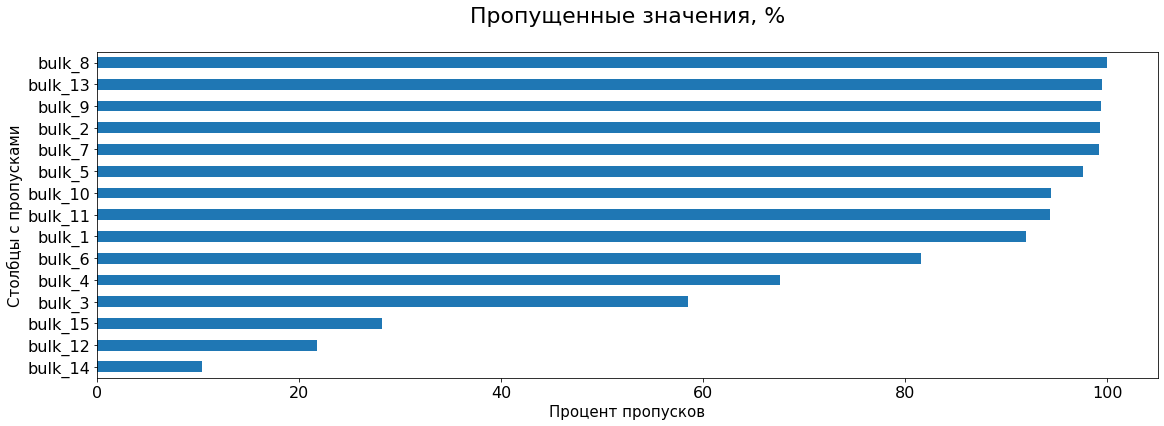

In [22]:
pass_value_barh(bulk)

Пропуски в данных о времени:

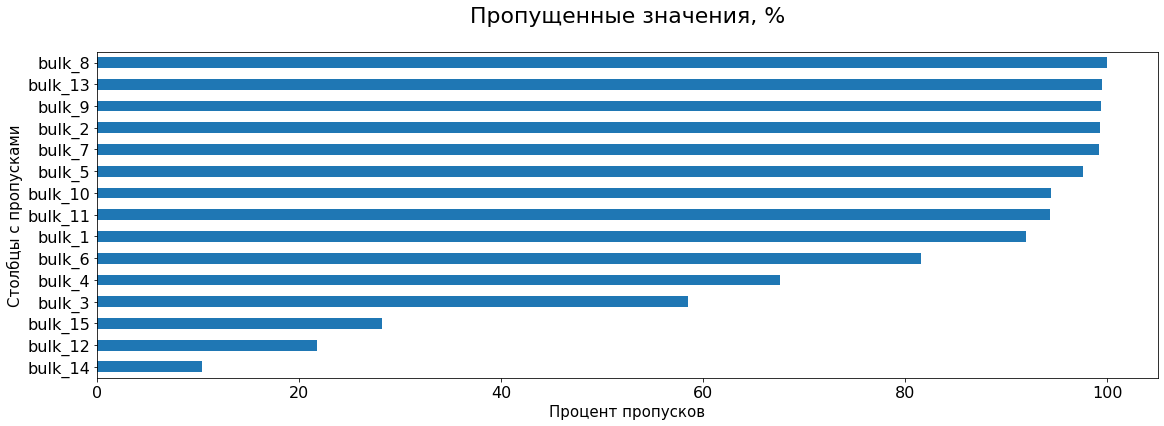

In [23]:
pass_value_barh(bulk_time)

Как мы можем увидеть, структура двух датасетов о сыпучих материалах индентична. В них огромное колчество пропусков, но их можно объяснить. Каждый столбец отвечает за определенный материал и вполне возможна ситауция, что в каждой партии может пригодиться доавление лишь каких-то определенных материалов. То есть пропуски в объеме можно заменить нулями, а вот в датасете со времени с ними ничего не сделать.

In [24]:
bulk = bulk.fillna(0)

#### Данные о проволочных материалах

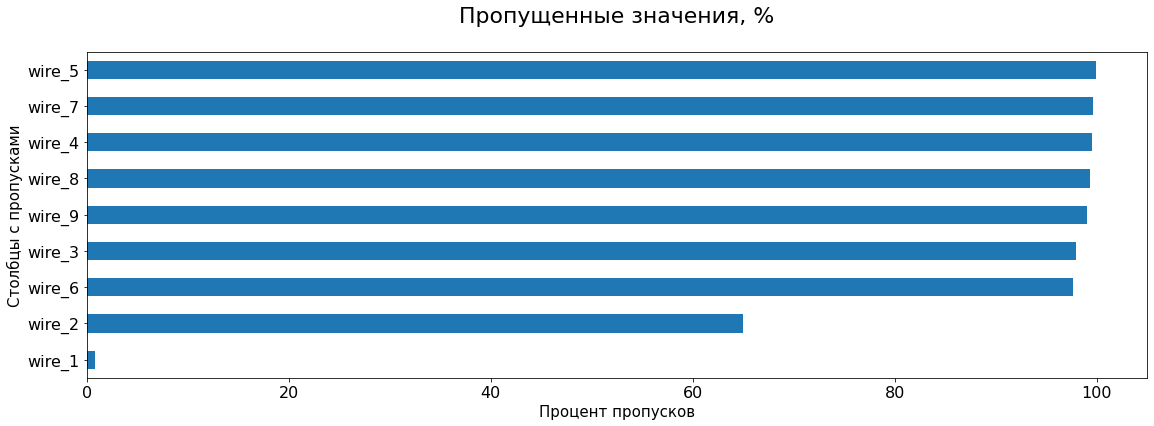

In [25]:
pass_value_barh(wire)

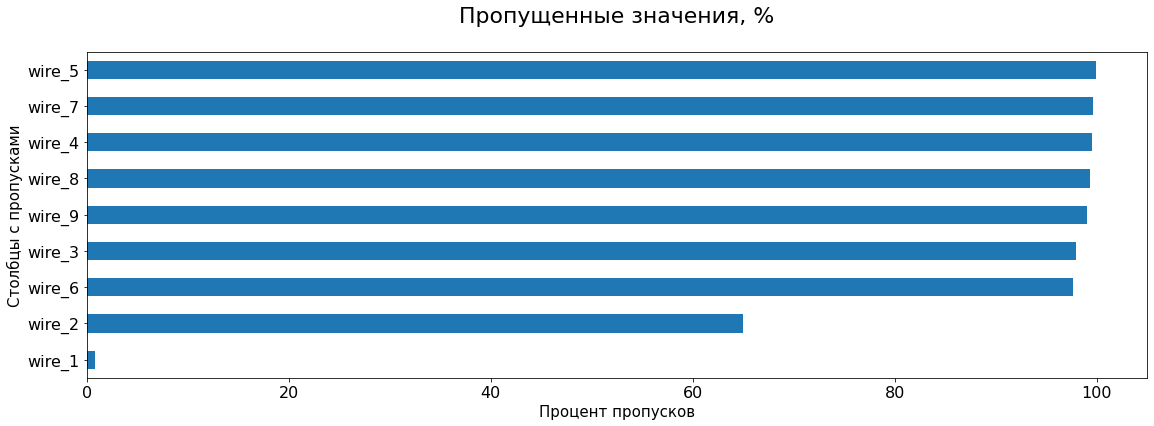

In [26]:
pass_value_barh(wire_time)

Сущность пропусков в этих датасетах полностью индентична прошлым двум. Соответственно и их замена будет проводится та же.

In [27]:
wire = wire.fillna(0)

#### Данные о температуре.

In [28]:
temp_nan = temp.fillna(0).copy()

In [29]:
rr = temp_nan.groupby('key').agg(
    первый_замер=('температура', 'first'),
    последний_замер=('температура', 'last'),
    время_первого_замера=('время_замера', 'min'),
    время_последнего_замера=('время_замера', 'max')
).reset_index()

In [30]:
rr = rr[(rr['первый_замер'] != 0) & (rr['последний_замер'] != 0)]


In [31]:
temp = temp[temp['key'].isin(rr['key'])]
temp = temp.dropna()
temp

,key,время_замера,температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0
3,1,2019-05-03 11:18:04,1601.0
4,1,2019-05-03 11:25:59,1606.0
...,...,...,...
13921,2499,2019-08-10 13:33:21,1569.0
13922,2499,2019-08-10 13:41:34,1604.0
13923,2499,2019-08-10 13:46:28,1593.0
13924,2499,2019-08-10 13:54:56,1588.0


Для корректной обработки пропусков в этом датасете, пришлось создать новый, в который вошли данные о первом и последнем замере температуры в каждой партии, так как интересуют нас именно они.В нем были удалены партии с пропусками в этих двух признаках, и дальше я вернулся к начальному датасету, оставив в нем только партии без критичских пропусков, чтобы в дальнейшем провести исследовательский анализ начального датасета. (в итоговый фрейм в любом случае поподут признаки именно из агрегированной версии этого датасета)

### Работа с дубликатами.

#### Данные об электродах

In [32]:
electrods.duplicated().sum()

0

Дубликатов нет.

#### Данные об объеме подаваемых сыпучих материалов.

In [33]:
bulk.duplicated().sum()

0

Дубликатов нет

#### Данные о времени подачи сыпучих материалов (время).

In [34]:
bulk_time.duplicated().sum()

0

Дубликатов нет.

#### Данные о продувке сплава газом

In [35]:
gas.duplicated().sum()

0

Дубликатов нет.

#### Данные о результатах измерения температуры.

In [36]:
temp.duplicated().sum()

0

Дубликатов нет.

#### Данные о проволочных материалах (объём).

In [37]:
wire.duplicated().sum()

0

Дубликатов нет.

#### Данные о проволочных материалах (время).

In [38]:
wire_time.duplicated().sum()

0

Дубликатов нет.

### Результаты.

В ходе предобработки было выполнено:

1) Изменение типа данных всех столбцов, содержащих в себе дату, на datetime64

2) Обработка пропущенных занчений во всех датасетах или удаление строк с ними, если такой возможности не было.

3) Было выяснено, что в данных нет дубликатов.

## Первичный исследовательский анализ.

### Создание функций

In [39]:
def hist_grath(data,t='',x='',y='',bins=60):
    data.hist(bins = bins, figsize = (15,3))
    plt.ylabel(y,fontsize=13)
    plt.title(t, fontsize=14)
    plt.xlabel(x,fontsize=13);
    return(data.describe())

In [40]:
def box_graph(data,y=''):
    data.plot(kind="box",figsize = (5,4))
    plt.ylabel(y,fontsize=13);
    return(data.describe())

### Данные об электродах


#### Активная мощность.

count    14876.000000
mean         0.662752
std          0.258885
min          0.223120
25%          0.467115
50%          0.599587
75%          0.830070
max          1.463773
Name: активная_мощность, dtype: float64

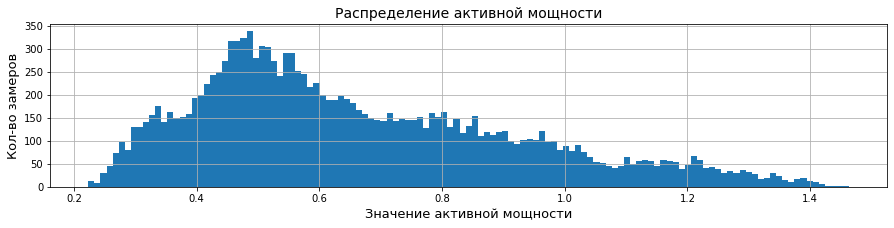

In [41]:
hist_grath(electrods['активная_мощность'],'Распределение активной мощности','Значение активной мощности','Кол-во замеров',125)

count    14876.000000
mean         0.662752
std          0.258885
min          0.223120
25%          0.467115
50%          0.599587
75%          0.830070
max          1.463773
Name: активная_мощность, dtype: float64

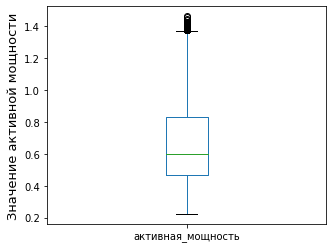

In [42]:
box_graph(electrods['активная_мощность'],'Значение активной мощности')

Видим пик на гистограмме у значения 0.5, а большинсвто значений находистя в диапозоне от 0.46 до 0.8.

#### Реактивная мощность.

count    14876.000000
mean         0.438986
std          5.873485
min       -715.479924
25%          0.337175
50%          0.441639
75%          0.608201
max          1.270284
Name: реактивная_мощность, dtype: float64

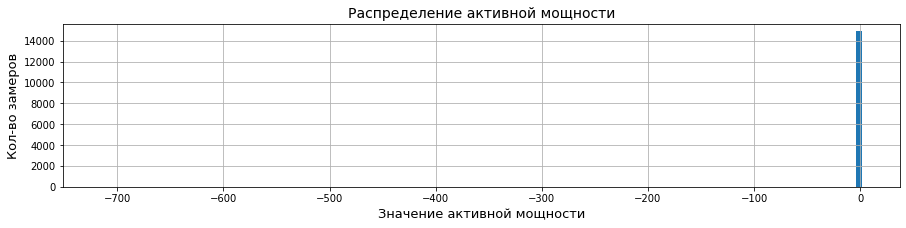

In [43]:
hist_grath(electrods['реактивная_мощность'],'Распределение активной мощности','Значение активной мощности','Кол-во замеров',125)

Видно присутствие аномальных выбросов, избавимся от них.

In [44]:
electrods[electrods['реактивная_мощность'] < 0]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924


In [45]:
electrods = electrods[electrods['key'] != 2116]

count    14872.000000
mean         0.487112
std          0.197623
min          0.153777
25%          0.337175
50%          0.441667
75%          0.608201
max          1.270284
Name: реактивная_мощность, dtype: float64

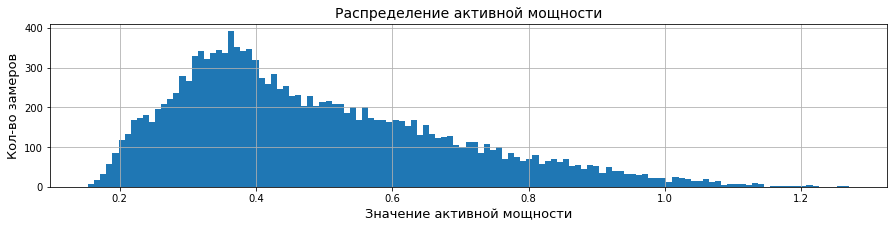

In [46]:
hist_grath(electrods['реактивная_мощность'],'Распределение активной мощности','Значение активной мощности','Кол-во замеров',125)

count    14872.000000
mean         0.487112
std          0.197623
min          0.153777
25%          0.337175
50%          0.441667
75%          0.608201
max          1.270284
Name: реактивная_мощность, dtype: float64

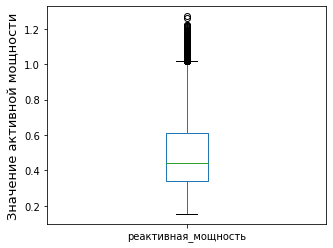

In [47]:
box_graph(electrods['реактивная_мощность'],'Значение активной мощности')

Большинство занчений находится в пределах от 0.33 до 0.6. Удалил аномальный выброс.

### Данные об объеме подаваемых сыпучих материалов

В этом датасете я буду рассматривать только самый многочисленный по ненулвым значениям признак, так как в остальных изначально было слишком много пропусков, чтобы делать какие то выводы из них. (Далее я суммирую объем всех металлов и создам новый признак для добавления в итоговый датасет. Так что когда буду анализировать уже его, какие то невыявленные аномалии сейчас будут учтены)

count    3129.000000
mean      152.706616
std        81.091421
min         0.000000
25%       104.000000
50%       148.000000
75%       202.000000
max       636.000000
Name: bulk_14, dtype: float64

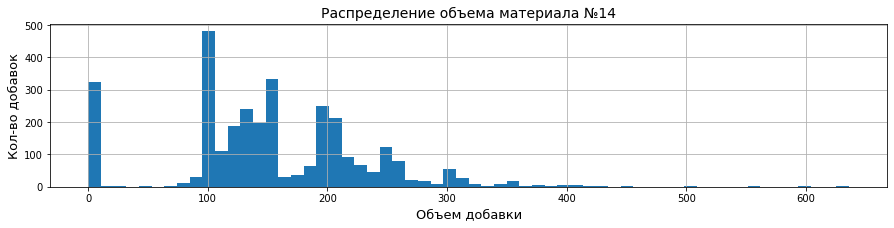

In [48]:
hist_grath(bulk['bulk_14'],'Распределение объема материала №14', 'Объем добавки','Кол-во добавок')

count    3129.000000
mean      152.706616
std        81.091421
min         0.000000
25%       104.000000
50%       148.000000
75%       202.000000
max       636.000000
Name: bulk_14, dtype: float64

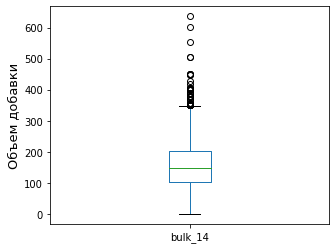

In [49]:
box_graph(bulk['bulk_14'],'Объем добавки')

По графику видно, что основные 4 пика кол-ва добавок располагаются на значениях: 0,100,150,200.

###  Данные о продувке сплава газом

count    3239.000000
mean       11.002062
std         6.220327
min         0.008399
25%         7.043089
50%         9.836267
75%        13.769915
max        77.995040
Name: газ_1, dtype: float64

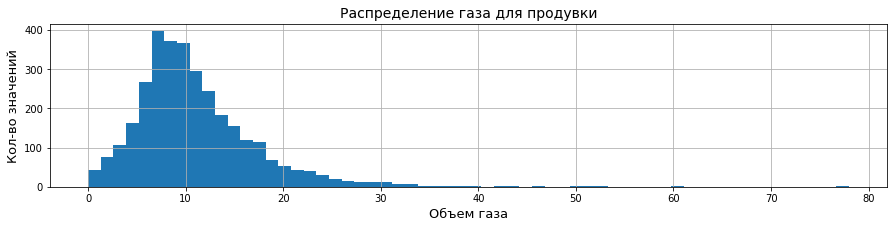

In [50]:
hist_grath(gas['газ_1'],'Распределение газа для продувки', 'Объем газа','Кол-во значений')

count    3239.000000
mean       11.002062
std         6.220327
min         0.008399
25%         7.043089
50%         9.836267
75%        13.769915
max        77.995040
Name: газ_1, dtype: float64

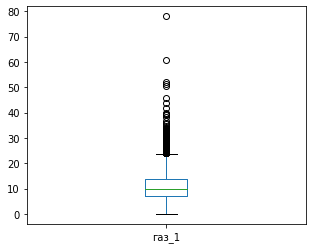

In [51]:
box_graph(gas['газ_1'])

Большинство значений расположено между 7 и 13. (тут,как и в прошлом датасете очевидно присутствие стастистичческих выбросов, но их я обработаю, когда создам итоговый датафрейм и разделю данные на тестовую и тренировочную выборки.

###  Данные о  результатах измерения температуры.

count    13926.000000
mean      1590.802671
std         19.845377
min       1191.000000
25%       1580.000000
50%       1590.000000
75%       1599.000000
max       1705.000000
Name: температура, dtype: float64

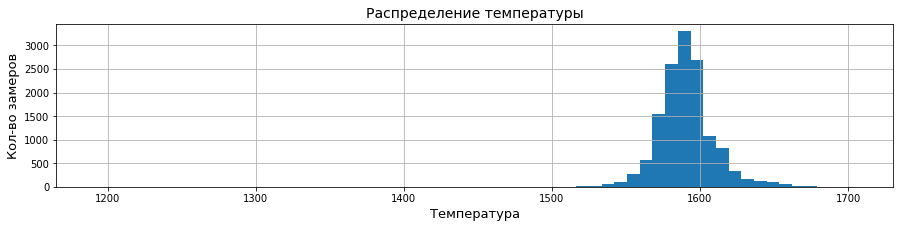

In [52]:
hist_grath(temp['температура'],'Распределение температуры', 'Температура','Кол-во замеров')

count    13926.000000
mean      1590.802671
std         19.845377
min       1191.000000
25%       1580.000000
50%       1590.000000
75%       1599.000000
max       1705.000000
Name: температура, dtype: float64

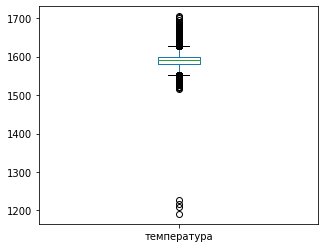

In [53]:
box_graph(temp['температура'])

In [54]:
rr = rr[(rr['первый_замер'] > 1300) & (rr['последний_замер'] > 1300)]

In [55]:
temp = temp[temp['key'].isin(rr['key'])]

count    13905.000000
mean      1590.924847
std         18.750314
min       1519.000000
25%       1580.000000
50%       1590.000000
75%       1599.000000
max       1705.000000
Name: температура, dtype: float64

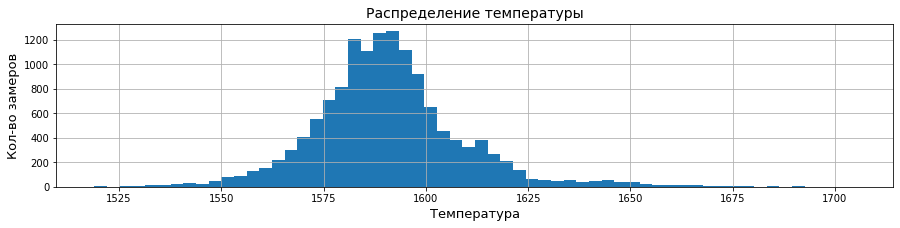

In [56]:
hist_grath(temp['температура'],'Распределение температуры', 'Температура','Кол-во замеров')

count    13905.000000
mean      1590.924847
std         18.750314
min       1519.000000
25%       1580.000000
50%       1590.000000
75%       1599.000000
max       1705.000000
Name: температура, dtype: float64

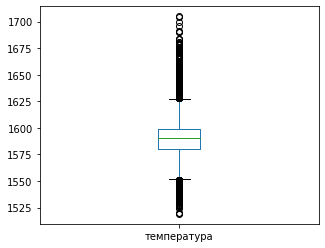

In [57]:
box_graph(temp['температура'])

Большинсвто значений расположено в диапозоне от 1580 до 1599.Были удалены аномлаии: температура ниже 1300.

### Данные о проволочных материалах (объём).

Механика анализа этих данных будет такой же, как и у сыпучих материалов.

count    3081.000000
mean      100.044411
std        42.841120
min         0.000000
25%        70.281120
50%       100.114563
75%       125.798405
max       330.314424
Name: wire_1, dtype: float64

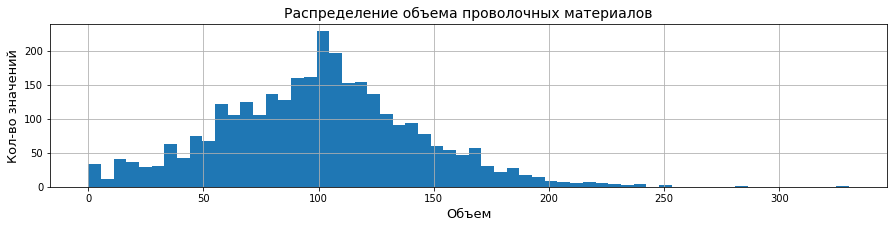

In [58]:
hist_grath(wire['wire_1'],'Распределение объема проволочных материалов', 'Объем','Кол-во значений')

count    3081.000000
mean      100.044411
std        42.841120
min         0.000000
25%        70.281120
50%       100.114563
75%       125.798405
max       330.314424
Name: wire_1, dtype: float64

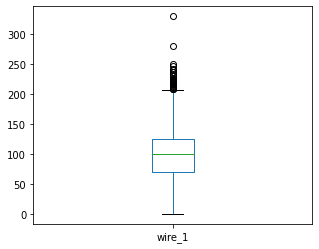

In [59]:
box_graph(wire['wire_1'])

Виден пик на значении 100, большинство значений распологается в диапазоне от 70 до 125. 

### Вывод. 

В ходе первичного исследовательского анализа было выяснено:
    
Активаня мощность - пик на гистограмме у значения 0.5, а большинсвто значений находистя в диапозоне от 0.46 до 0.8.

Реактивная мощность - большинство занчений находится в пределах от 0.33 до 0.6.

Bulk 14 - основные 4 пика кол-ва добавок располагаются на значениях: 0,100,150,200.
    
Газ - Большинство значений расположено между 7 и 13.

Температура - Большинсвто значений расположено в диапозоне от 1580 до 1599

Wire 1 - виден пик на значении 100, большинство значений распологается в диапазоне от 70 до 125. 



## Создание новых признаков.

### Работа с электродами.

In [60]:
electrods.head()

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691


In [61]:
electrods['measurement_time'] = (electrods['конец_нагрева_дугой'] - electrods['начало_нагрева_дугой']).dt.total_seconds()

In [62]:
el_gr = electrods.groupby('key').agg(
    общее_время_нагрева=('measurement_time', 'sum'),
    средняя_активная_мощность=('активная_мощность', 'mean'),
    средняя_реактивная_мощность=('реактивная_мощность', 'mean'),
).reset_index()

In [63]:
el_gr.head()

,key,общее_время_нагрева,средняя_активная_мощность,средняя_реактивная_мощность
0,1,1098.0,0.607346,0.428564
1,2,811.0,0.534852,0.363339
2,3,655.0,0.812728,0.587491
3,4,741.0,0.676622,0.514248
4,5,869.0,0.563238,0.421998


Из датасета про электроды был создан новый, включающий в себя общее время нагрева дугой в секундах, среднюю активную и реактивную мощность на каждую партию.

### Работа с сыпучими материалами.

In [64]:
bulk['sum_bulk'] =  bulk.iloc[:, 1:16].sum(axis=1)

In [65]:
sum_bulk = bulk[['key','sum_bulk']]

In [66]:
sum_bulk.head()

,key,sum_bulk
0,1,553.0
1,2,582.0
2,3,544.0
3,4,595.0
4,5,584.0


Из датафрейма об объеме сыпучих материалов был создан новый признак, включающий в себя сумму всех металлов. Датасет со временем подачи этих металлов я исплоьзовать не буду, так как ничего полезного из него вытянуть нельзя.


### Работа с температурой.

Воспользуемся уже созданным датафреймом rr

In [67]:
rr.head()

,key,первый_замер,последний_замер,время_первого_замера,время_последнего_замера
0,1,1571.0,1613.0,2019-05-03 11:02:04,2019-05-03 11:30:38
1,2,1581.0,1602.0,2019-05-03 11:34:04,2019-05-03 11:55:09
2,3,1596.0,1599.0,2019-05-03 12:06:44,2019-05-03 12:35:57
3,4,1601.0,1625.0,2019-05-03 12:39:27,2019-05-03 12:59:47
4,5,1576.0,1602.0,2019-05-03 13:11:03,2019-05-03 13:36:39


In [68]:
rr['время_до_замера'] = (rr['время_последнего_замера'] - rr['время_первого_замера']).dt.total_seconds()

In [69]:
rr = rr.drop(['время_первого_замера', 'время_последнего_замера'], axis=1)


In [70]:
rr.head()

,key,первый_замер,последний_замер,время_до_замера
0,1,1571.0,1613.0,1714.0
1,2,1581.0,1602.0,1265.0
2,3,1596.0,1599.0,1753.0
3,4,1601.0,1625.0,1220.0
4,5,1576.0,1602.0,1536.0


К уже созданному датафрейму rr, который включает в себя температуру перовго и посоледнего замера, а также время их измерения, я добавил время от первого замера до последнего в секундах.

### Работа с проволкой.

In [71]:
wire['sum_wire'] =  wire.iloc[:, 1:10].sum(axis=1)

In [72]:
sum_wire = wire[['key','sum_wire']]

In [73]:
sum_wire.head()

,key,sum_wire
0,1,60.059998
1,2,96.052315
2,3,91.160157
3,4,89.063515
4,5,98.352796


Из датасета об объеме проволочных материалов был созданном новый признак, являющийся суммой всех материалов.

## Создание итогового датафрейма.

In [74]:
data = (rr.merge(sum_bulk, on='key', how='inner')
             .merge(sum_wire, on='key', how='inner')
             .merge(el_gr, on='key', how='inner').merge(gas, on='key', how='inner'))

In [75]:
data.head()

,key,первый_замер,последний_замер,время_до_замера,sum_bulk,sum_wire,общее_время_нагрева,средняя_активная_мощность,средняя_реактивная_мощность,газ_1
0,1,1571.0,1613.0,1714.0,553.0,60.059998,1098.0,0.607346,0.428564,29.749986
1,2,1581.0,1602.0,1265.0,582.0,96.052315,811.0,0.534852,0.363339,12.555561
2,3,1596.0,1599.0,1753.0,544.0,91.160157,655.0,0.812728,0.587491,28.554793
3,4,1601.0,1625.0,1220.0,595.0,89.063515,741.0,0.676622,0.514248,18.841219
4,5,1576.0,1602.0,1536.0,584.0,98.352796,869.0,0.563238,0.421998,5.413692


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2324 entries, 0 to 2323
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   key                          2324 non-null   int64  
 1   первый_замер                 2324 non-null   float64
 2   последний_замер              2324 non-null   float64
 3   время_до_замера              2324 non-null   float64
 4   sum_bulk                     2324 non-null   float64
 5   sum_wire                     2324 non-null   float64
 6   общее_время_нагрева          2324 non-null   float64
 7   средняя_активная_мощность    2324 non-null   float64
 8   средняя_реактивная_мощность  2324 non-null   float64
 9   газ_1                        2324 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 199.7 KB


### Разбиеине на тренировочную и тестовую выборки.

In [77]:
df_train, df_test = train_test_split(data, test_size=0.25, random_state=RANDOM_STATE) 

Датасет был разделен на 2 в соотношении 3 : 1.

## Исследовательский анализ данных.

### Температура при первом замере.

#### Тренировчная выборка.

count    1743.000000
mean     1587.053356
std        23.729291
min      1519.000000
25%      1571.000000
50%      1586.000000
75%      1602.500000
max      1660.000000
Name: первый_замер, dtype: float64

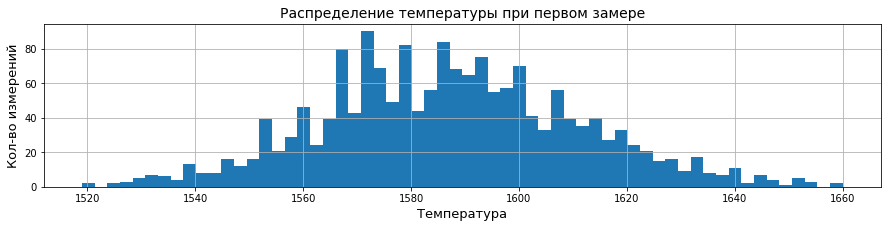

In [78]:
hist_grath(df_train['первый_замер'],'Распределение температуры при первом замере','Температура','Кол-во измерений')

count    1743.000000
mean     1587.053356
std        23.729291
min      1519.000000
25%      1571.000000
50%      1586.000000
75%      1602.500000
max      1660.000000
Name: первый_замер, dtype: float64

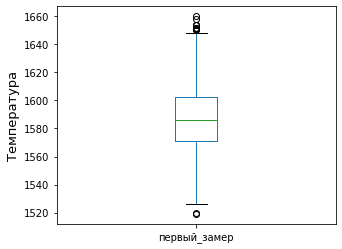

In [79]:
box_graph(df_train['первый_замер'],'Температура')

In [80]:
df_train = df_train[(df_train['первый_замер'] > 1525) & (df_train['первый_замер'] < 1675)]

count    1741.000000
mean     1587.130959
std        23.632071
min      1526.000000
25%      1571.000000
50%      1587.000000
75%      1603.000000
max      1660.000000
Name: первый_замер, dtype: float64

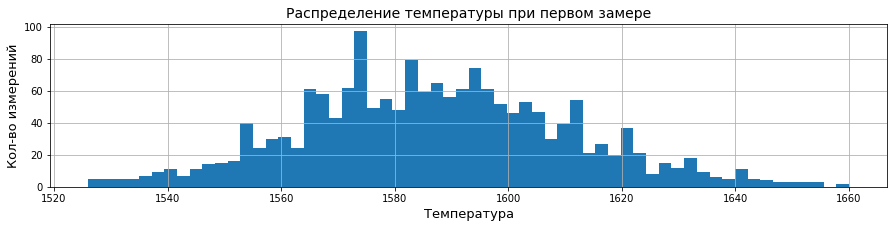

In [81]:
hist_grath(df_train['первый_замер'],'Распределение температуры при первом замере','Температура','Кол-во измерений')

count    1741.000000
mean     1587.130959
std        23.632071
min      1526.000000
25%      1571.000000
50%      1587.000000
75%      1603.000000
max      1660.000000
Name: первый_замер, dtype: float64

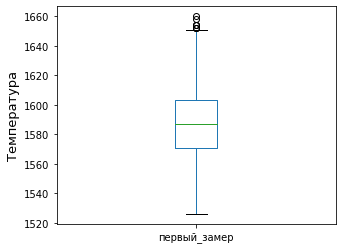

In [82]:
box_graph(df_train['первый_замер'],'Температура')

Пик значений на отметке в 1575. Большинство значений находися в диапазоне от 1571 до 1603. Были удалены выбросы: строки, где значение температуры было ниже 1525 или выше 1675.

#### Тестовая выборка.

count     581.000000
mean     1588.314974
std        23.314468
min      1520.000000
25%      1572.000000
50%      1587.000000
75%      1604.000000
max      1660.000000
Name: первый_замер, dtype: float64

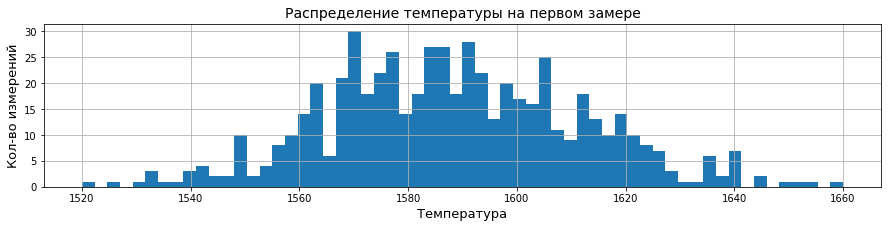

In [83]:
hist_grath(df_test['первый_замер'],'Распределение температуры на первом замере','Температура','Кол-во измерений')

count     581.000000
mean     1588.314974
std        23.314468
min      1520.000000
25%      1572.000000
50%      1587.000000
75%      1604.000000
max      1660.000000
Name: первый_замер, dtype: float64

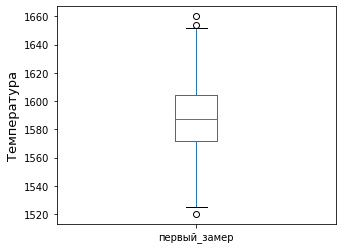

In [84]:
box_graph(df_test['первый_замер'],'Температура')

Пик занчений на отметке в 1570. Большинство значений находится в диапазоне от 1569 до 1602.

### Температура на последнем замере.

#### Тренировочная выборка.

count    1741.000000
mean     1593.426192
std        11.291278
min      1543.000000
25%      1587.000000
50%      1593.000000
75%      1598.000000
max      1653.000000
Name: последний_замер, dtype: float64

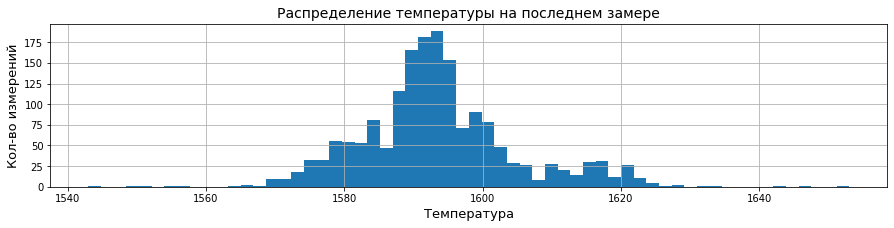

In [85]:
hist_grath(df_train['последний_замер'],'Распределение температуры на последнем замере','Температура','Кол-во измерений')

count    1741.000000
mean     1593.426192
std        11.291278
min      1543.000000
25%      1587.000000
50%      1593.000000
75%      1598.000000
max      1653.000000
Name: последний_замер, dtype: float64

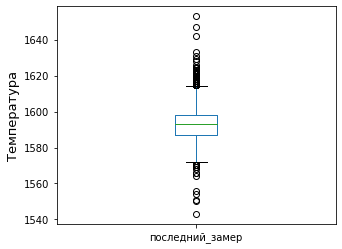

In [86]:
box_graph(df_train['последний_замер'],'Температура')

Пик значений на отметке в 1588. Большинство значений находится в промежутке от 1588 до 1598. Есть статистические выбросы, но так как это целевой признак, трогать их не буду.

#### Тестовая выборка.

count     581.000000
mean     1593.268503
std        10.937291
min      1541.000000
25%      1588.000000
50%      1593.000000
75%      1598.000000
max      1626.000000
Name: последний_замер, dtype: float64

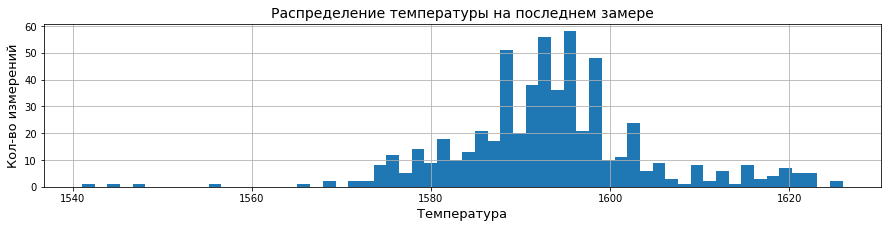

In [87]:
hist_grath(df_test['последний_замер'],'Распределение температуры на последнем замере','Температура','Кол-во измерений')

count     581.000000
mean     1593.268503
std        10.937291
min      1541.000000
25%      1588.000000
50%      1593.000000
75%      1598.000000
max      1626.000000
Name: последний_замер, dtype: float64

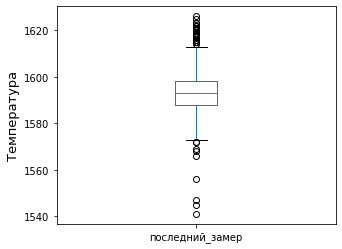

In [88]:
box_graph(df_test['последний_замер'],'Температура')

Большинство значений находится в диапозоне от 1587 до 1597.

### Время от первого замера до последнего.

#### Тренировочная выборка.

count     1741.000000
mean      2308.921310
std       1301.623073
min        370.000000
25%       1596.000000
50%       2045.000000
75%       2783.000000
max      23674.000000
Name: время_до_замера, dtype: float64

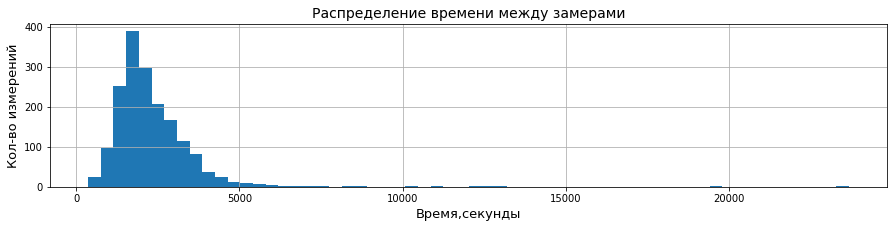

In [89]:
hist_grath(df_train['время_до_замера'],'Распределение времени между замерами','Время,секунды','Кол-во измерений')

count     1741.000000
mean      2308.921310
std       1301.623073
min        370.000000
25%       1596.000000
50%       2045.000000
75%       2783.000000
max      23674.000000
Name: время_до_замера, dtype: float64

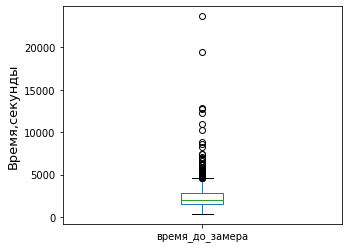

In [90]:
box_graph(df_train['время_до_замера'],'Время,секунды')

In [91]:
df_train = df_train[df_train['время_до_замера'] < 6500]

count    1725.000000
mean     2231.416232
std       923.926330
min       370.000000
25%      1594.000000
50%      2033.000000
75%      2758.000000
max      6236.000000
Name: время_до_замера, dtype: float64

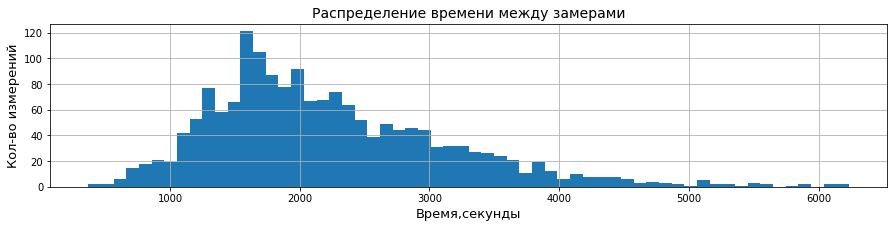

In [92]:
hist_grath(df_train['время_до_замера'],'Распределение времени между замерами','Время,секунды','Кол-во измерений')

count    1725.000000
mean     2231.416232
std       923.926330
min       370.000000
25%      1594.000000
50%      2033.000000
75%      2758.000000
max      6236.000000
Name: время_до_замера, dtype: float64

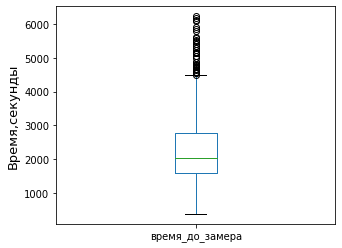

In [93]:
box_graph(df_train['время_до_замера'],'Время,секунды')

Большинство значений находится в пределах от 1590 до 2758. Были удалены выбросы: строки, где значение превышало 6500 секунд (108 минут)

#### Тестовая выборка.

count      581.000000
mean      2368.447504
std       1614.432299
min        339.000000
25%       1532.000000
50%       2047.000000
75%       2814.000000
max      21331.000000
Name: время_до_замера, dtype: float64

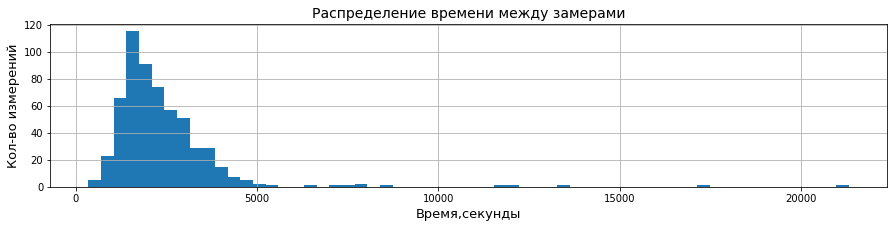

In [94]:
hist_grath(df_test['время_до_замера'],'Распределение времени между замерами','Время,секунды','Кол-во измерений')

count      581.000000
mean      2368.447504
std       1614.432299
min        339.000000
25%       1532.000000
50%       2047.000000
75%       2814.000000
max      21331.000000
Name: время_до_замера, dtype: float64

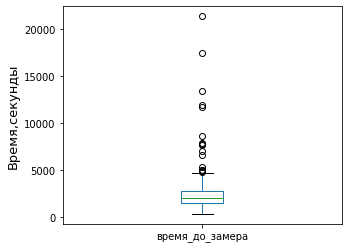

In [95]:
box_graph(df_test['время_до_замера'],'Время,секунды')

In [96]:
df_test = df_test[df_test['время_до_замера'] < 10000]

count     576.000000
mean     2257.435764
std      1036.432746
min       339.000000
25%      1529.500000
50%      2045.000000
75%      2790.250000
max      8635.000000
Name: время_до_замера, dtype: float64

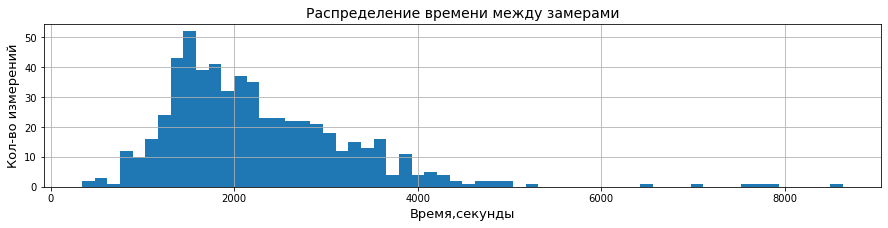

In [97]:
hist_grath(df_test['время_до_замера'],'Распределение времени между замерами','Время,секунды','Кол-во измерений')

count     576.000000
mean     2257.435764
std      1036.432746
min       339.000000
25%      1529.500000
50%      2045.000000
75%      2790.250000
max      8635.000000
Name: время_до_замера, dtype: float64

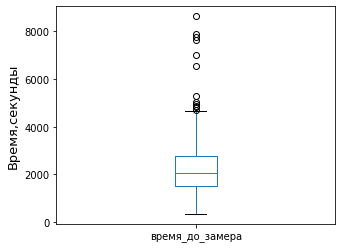

In [98]:
box_graph(df_test['время_до_замера'],'Время,секунды')

Большинство значений находится в диапозоне от 1538 до 2750. Здесь все удаил некоторые строки, где время превышало 10000 секунд (чуть меньше 3 часов), так как это уже похоже больше на аномлаьные выбросы, а не статичстические.

### Сыпучие материаллы.

#### Тренировочная выборка.

count    1725.000000
mean      605.746087
std       282.195970
min        19.000000
25%       430.000000
50%       609.000000
75%       790.000000
max      1569.000000
Name: sum_bulk, dtype: float64

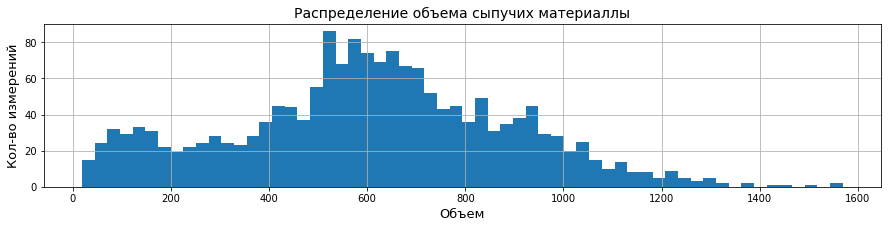

In [99]:
hist_grath(df_train['sum_bulk'],'Распределение объема сыпучих материаллы','Объем','Кол-во измерений')

count    1725.000000
mean      605.746087
std       282.195970
min        19.000000
25%       430.000000
50%       609.000000
75%       790.000000
max      1569.000000
Name: sum_bulk, dtype: float64

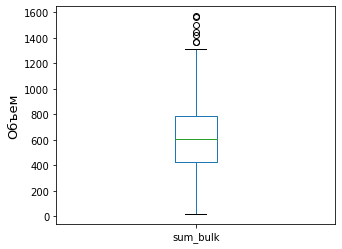

In [100]:
box_graph(df_train['sum_bulk'],'Объем')

Большинство значений расположено в диапазоне от 434 до 789.

#### Тестовая выборка.

count     576.000000
mean      607.272569
std       274.655434
min        19.000000
25%       458.000000
50%       606.500000
75%       792.250000
max      1430.000000
Name: sum_bulk, dtype: float64

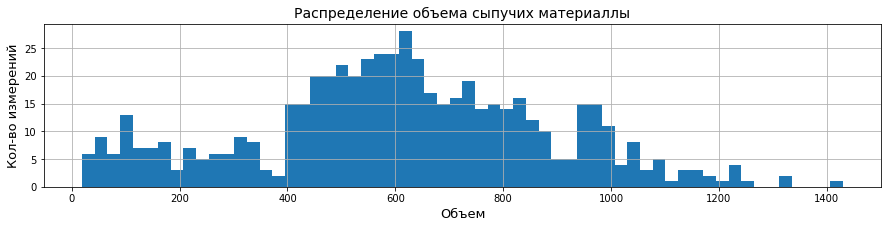

In [101]:
hist_grath(df_test['sum_bulk'],'Распределение объема сыпучих материаллы','Объем','Кол-во измерений')

count     576.000000
mean      607.272569
std       274.655434
min        19.000000
25%       458.000000
50%       606.500000
75%       792.250000
max      1430.000000
Name: sum_bulk, dtype: float64

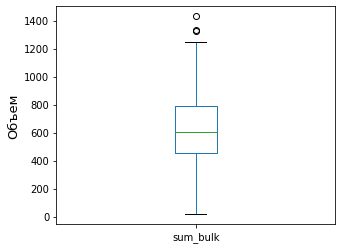

In [102]:
box_graph(df_test['sum_bulk'],'Объем')

Большинство значений расположено в диапозоне от 450 до 796.

### Проволочные материалы.

#### Тренировачная выборка.

count    1725.000000
mean      125.769688
std        64.578218
min        10.046400
25%        89.150879
50%       117.280792
75%       152.137435
max       568.777664
Name: sum_wire, dtype: float64

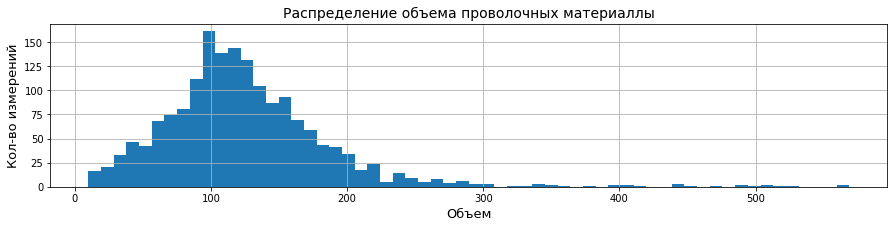

In [103]:
hist_grath(df_train['sum_wire'],'Распределение объема проволочных материаллы','Объем','Кол-во измерений')

count    1725.000000
mean      125.769688
std        64.578218
min        10.046400
25%        89.150879
50%       117.280792
75%       152.137435
max       568.777664
Name: sum_wire, dtype: float64

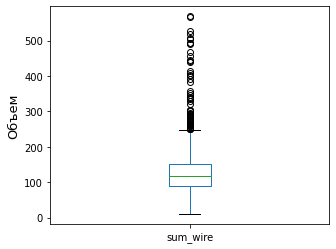

In [104]:
box_graph(df_train['sum_wire'],'Объем')

In [105]:
df_train = df_train[df_train['sum_wire'] < 350] 

count    1703.000000
mean      121.501191
std        52.397104
min        10.046400
25%        88.374516
50%       116.491435
75%       151.217043
max       347.793691
Name: sum_wire, dtype: float64

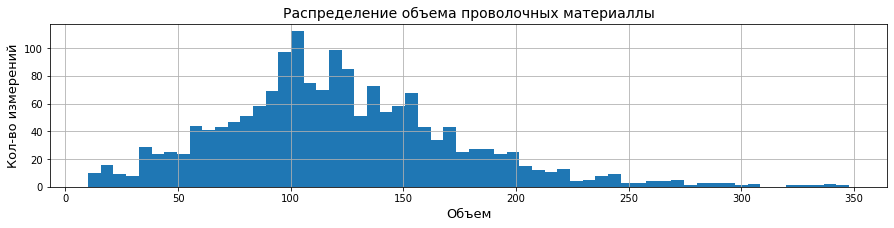

In [106]:
hist_grath(df_train['sum_wire'],'Распределение объема проволочных материаллы','Объем','Кол-во измерений')

count    1703.000000
mean      121.501191
std        52.397104
min        10.046400
25%        88.374516
50%       116.491435
75%       151.217043
max       347.793691
Name: sum_wire, dtype: float64

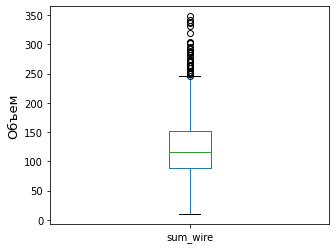

In [107]:
box_graph(df_train['sum_wire'],'Объем')

Четко виден пик на значении в 100. Большинство значений распределены в промежутке от 88 до 151.

#### Тестовая выборка.

count    576.000000
mean     121.712367
std       60.091965
min        1.918800
25%       87.205557
50%      112.041277
75%      145.793700
max      483.481659
Name: sum_wire, dtype: float64

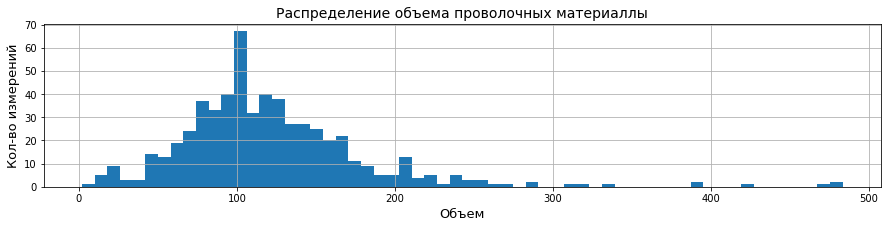

In [108]:
hist_grath(df_test['sum_wire'],'Распределение объема проволочных материаллы','Объем','Кол-во измерений')

count    576.000000
mean     121.712367
std       60.091965
min        1.918800
25%       87.205557
50%      112.041277
75%      145.793700
max      483.481659
Name: sum_wire, dtype: float64

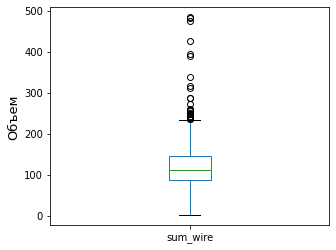

In [109]:
box_graph(df_test['sum_wire'],'Объем')

Также виден пик на значении в 100. Большинство значений расположено в промежутке от 7 до 147

### Активная мощность.

#### Тренировочная выобрка.

count    1703.000000
mean        0.662174
std         0.127289
min         0.326933
25%         0.571434
50%         0.653285
75%         0.739297
max         1.243889
Name: средняя_активная_мощность, dtype: float64

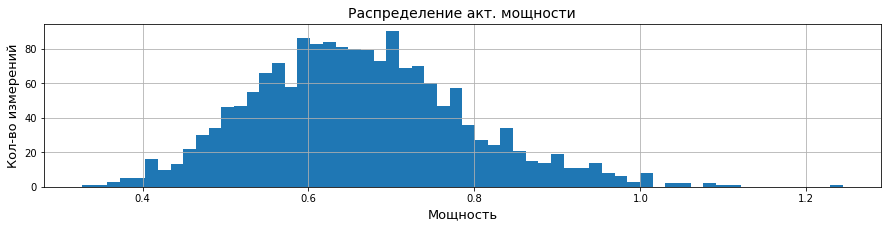

In [110]:
hist_grath(df_train['средняя_активная_мощность'],'Распределение акт. мощности','Мощность','Кол-во измерений')

count    1703.000000
mean        0.662174
std         0.127289
min         0.326933
25%         0.571434
50%         0.653285
75%         0.739297
max         1.243889
Name: средняя_активная_мощность, dtype: float64

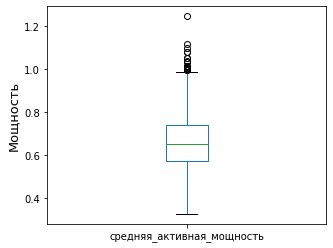

In [111]:
box_graph(df_train['средняя_активная_мощность'],'Мощность')

Большинство значений расположено в промежутке от 0.57 до 0.73.

#### Тестовая выборка.

count    576.000000
mean       0.668722
std        0.132168
min        0.267676
25%        0.585537
50%        0.660391
75%        0.747355
max        1.201746
Name: средняя_активная_мощность, dtype: float64

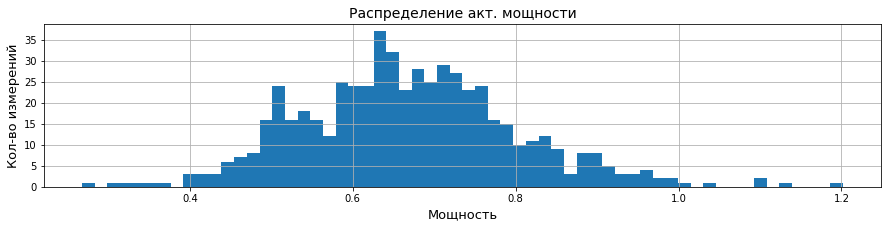

In [112]:
hist_grath(df_test['средняя_активная_мощность'],'Распределение акт. мощности','Мощность','Кол-во измерений')

count    576.000000
mean       0.668722
std        0.132168
min        0.267676
25%        0.585537
50%        0.660391
75%        0.747355
max        1.201746
Name: средняя_активная_мощность, dtype: float64

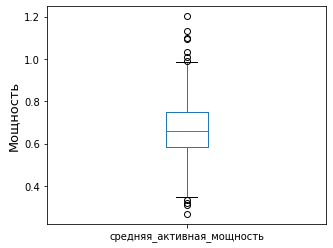

In [113]:
box_graph(df_test['средняя_активная_мощность'],'Мощность')

Большинство значений расположено в промежутке от 0.58 до 0.75.

### Реактивная мощность.

#### Тренировочная выборка.

count    1703.000000
mean        0.486804
std         0.096647
min         0.229831
25%         0.417436
50%         0.482978
75%         0.544297
max         0.960763
Name: средняя_реактивная_мощность, dtype: float64

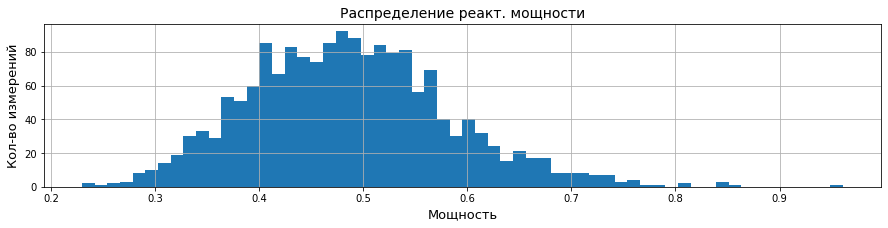

In [114]:
hist_grath(df_train['средняя_реактивная_мощность'],'Распределение реакт. мощности','Мощность','Кол-во измерений')

count    1703.000000
mean        0.486804
std         0.096647
min         0.229831
25%         0.417436
50%         0.482978
75%         0.544297
max         0.960763
Name: средняя_реактивная_мощность, dtype: float64

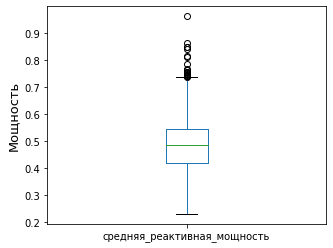

In [115]:
box_graph(df_train['средняя_реактивная_мощность'],'Мощность')

Большинство значений расположен в промежутке от 0.41 до 0.54.

#### Тестовая выборка.

count    576.000000
mean       0.493916
std        0.102530
min        0.196228
25%        0.428789
50%        0.489148
75%        0.550051
max        0.875916
Name: средняя_реактивная_мощность, dtype: float64

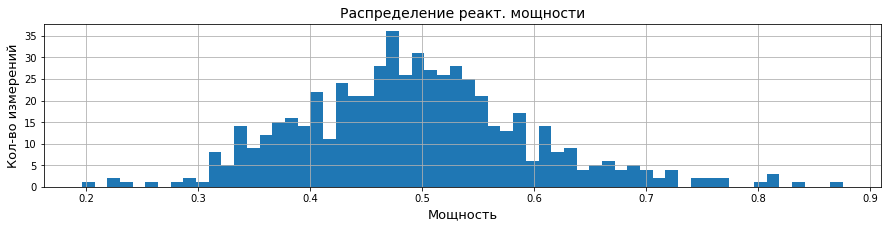

In [116]:
hist_grath(df_test['средняя_реактивная_мощность'],'Распределение реакт. мощности','Мощность','Кол-во измерений')

count    576.000000
mean       0.493916
std        0.102530
min        0.196228
25%        0.428789
50%        0.489148
75%        0.550051
max        0.875916
Name: средняя_реактивная_мощность, dtype: float64

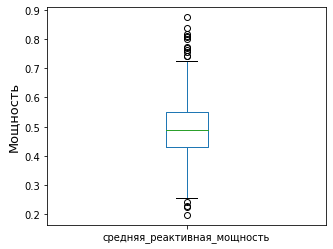

In [117]:
box_graph(df_test['средняя_реактивная_мощность'],'Мощность')

Большинсвто значений расположено в промежутке от 0.41 до 0.55.

### Время нагрева.

#### Тренировочная выборка.

count    1703.000000
mean      802.282443
std       319.796450
min        57.000000
25%       580.500000
50%       776.000000
75%      1001.500000
max      2247.000000
Name: общее_время_нагрева, dtype: float64

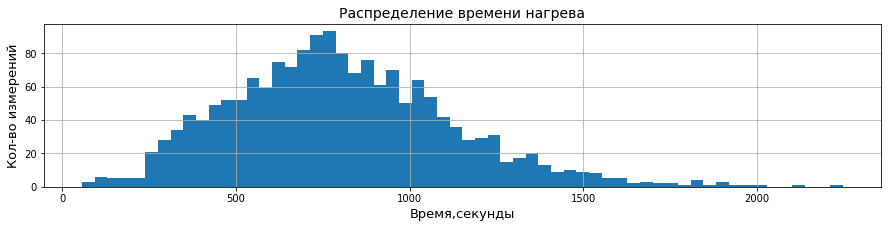

In [118]:
hist_grath(df_train['общее_время_нагрева'],'Распределение времени нагрева','Время,секунды','Кол-во измерений')

count    1703.000000
mean      802.282443
std       319.796450
min        57.000000
25%       580.500000
50%       776.000000
75%      1001.500000
max      2247.000000
Name: общее_время_нагрева, dtype: float64

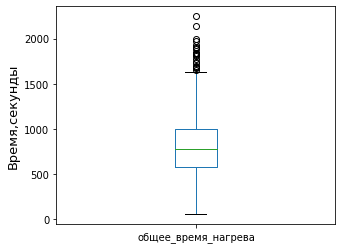

In [119]:
box_graph(df_train['общее_время_нагрева'],'Время,секунды')

Большинство значений находится в диапозоне от 586 до 996.

#### Тестовая выборка.

count     576.000000
mean      788.727431
std       308.940839
min        95.000000
25%       577.250000
50%       775.500000
75%       956.250000
max      2065.000000
Name: общее_время_нагрева, dtype: float64

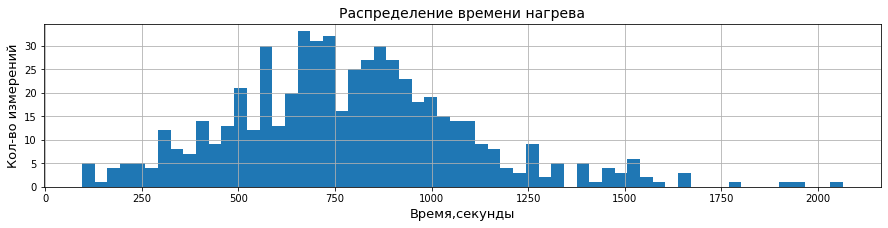

In [120]:
hist_grath(df_test['общее_время_нагрева'],'Распределение времени нагрева','Время,секунды','Кол-во измерений')

count     576.000000
mean      788.727431
std       308.940839
min        95.000000
25%       577.250000
50%       775.500000
75%       956.250000
max      2065.000000
Name: общее_время_нагрева, dtype: float64

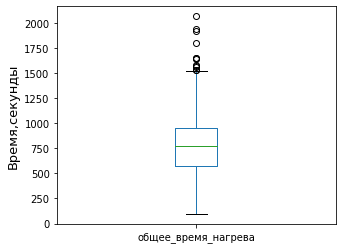

In [121]:
box_graph(df_test['общее_время_нагрева'],'Время,секунды')

Большинство значений находится в диапозоне от 564 до 952.

### Газ

#### Тренировочная выбокрка.

count    1703.000000
mean       11.244675
std         6.086080
min         0.008399
25%         7.241030
50%        10.108007
75%        14.219282
max        60.935689
Name: газ_1, dtype: float64

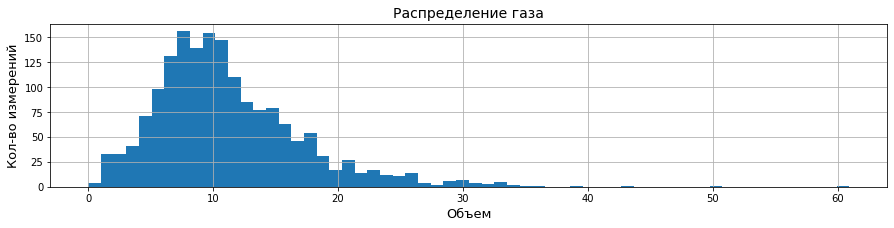

In [122]:
hist_grath(df_train['газ_1'],'Распределение газа','Объем','Кол-во измерений')

count    1703.000000
mean       11.244675
std         6.086080
min         0.008399
25%         7.241030
50%        10.108007
75%        14.219282
max        60.935689
Name: газ_1, dtype: float64

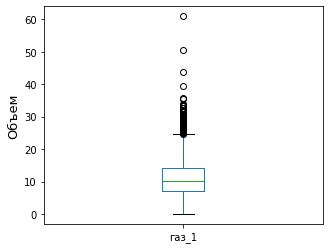

In [123]:
box_graph(df_train['газ_1'],'Объем')

In [124]:
df_train = df_train[df_train['газ_1'] < 39]

count    1699.000000
mean       11.156612
std         5.802418
min         0.008399
25%         7.235540
50%        10.088416
75%        14.193609
max        35.769306
Name: газ_1, dtype: float64

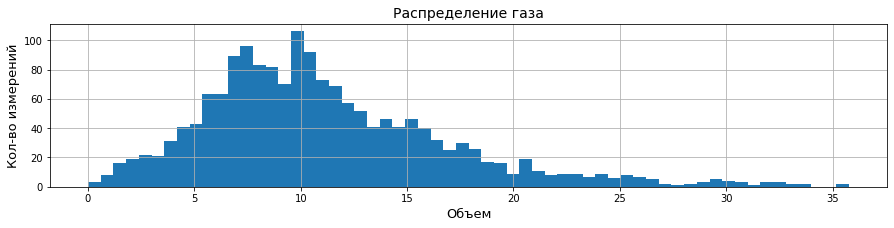

In [125]:
hist_grath(df_train['газ_1'],'Распределение газа','Объем','Кол-во измерений')

count    1699.000000
mean       11.156612
std         5.802418
min         0.008399
25%         7.235540
50%        10.088416
75%        14.193609
max        35.769306
Name: газ_1, dtype: float64

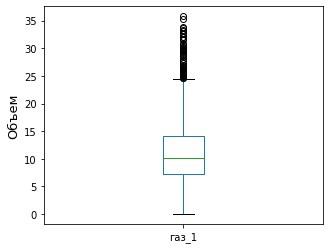

In [126]:
box_graph(df_train['газ_1'],'Объем')

Четко виден пик на значении в 10.Большинсвто занчений расположено в диапозоне от 7 до 14. Были удалены выбросы: строки, где значение выше 39.

#### Тестовая выборка.

count    576.000000
mean      11.062372
std        5.850124
min        0.863448
25%        7.300364
50%        9.859140
75%       13.518307
max       41.854643
Name: газ_1, dtype: float64

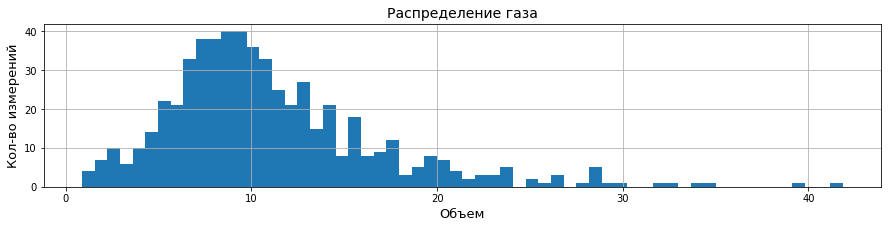

In [127]:
hist_grath(df_test['газ_1'],'Распределение газа','Объем','Кол-во измерений')

count    576.000000
mean      11.062372
std        5.850124
min        0.863448
25%        7.300364
50%        9.859140
75%       13.518307
max       41.854643
Name: газ_1, dtype: float64

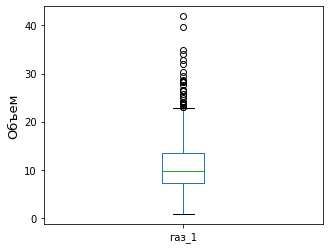

In [128]:
box_graph(df_test['газ_1'],'Объем')

Большинство занчений лежит в пределах от 7 до 13

### Выводы.

В итоге оказалось (Это было вполне ожидаемо), что распределение признаков в тестовой и тренировочной выборке одинаковое. Статистические выбросы удалялись только из тренировочной выборки.
Вот, что было выяснено про каждый признак:

1) Температура на первом замере - Тренировочная выборка: пик значений на отметке в 1575. Большинство значений находися в диапазоне от 1571 до 1603; Тестовая выборка - Пик занчений на отметке в 1570. Большинство значений находится в диапазоне от 1569 до 1602.

2) Температура на последнем замере - Тренировочная выборка: Пик значений на отметке в 1588. Большинство значений находится в промежутке от 1588 до 1598.; Тестовая выборка - Большинство значений находится в диапозоне от 1587 до 1597.

3) Время между замерами температуры - Тренировочная выборка: Большинство значений находится в пределах от 1590 до 2758; Тестовая выборка - Большинство значений находится в диапозоне от 1538 до 2750. 

4) Объем сыпучих материаллов - Тренировочная выборка: Большинство значений расположено в диапазоне от 434 до 789.; Тестовая выборка - Большинство значений расположено в диапозоне от 450 до 796.

5) Объем проволочных материаллов - Тренировочная выборка: Четко виден пик на значении в 100. Большинство значений распределены в промежутке от 88 до 151; Тестовая выборка - Также виден пик на значении в 100. Большинство значений расположено в промежутке от 7 до 147.

6) Активная мощность - Тренировочная выборка: Большинство значений расположено в промежутке от 0.57 до 0.73; Тестовая выборка - Большинство значений расположено в промежутке от 0.58 до 0.75.

7) Реактивная мощность - Тренировочная выборка: Большинство значений расположен в промежутке от 0.41 до 0.54.; Тестовая выборка - Большинсвто значений расположено в промежутке от 0.41 до 0.55.

8) Время нагрева - Тренировочная выборка: Большинство значений находится в диапозоне от 586 до 996.; Тестовая выборка - Большинство значений находится в диапозоне от 564 до 952.

9) Газ - Тренировочная выборка: Четко виден пик на значении в 10.Большинсвто занчений расположено в диапозоне от 7 до 14; Тестовая выборка -Большинство занчений лежит в пределах от 7 до 13.



## Коррляционный анализ.

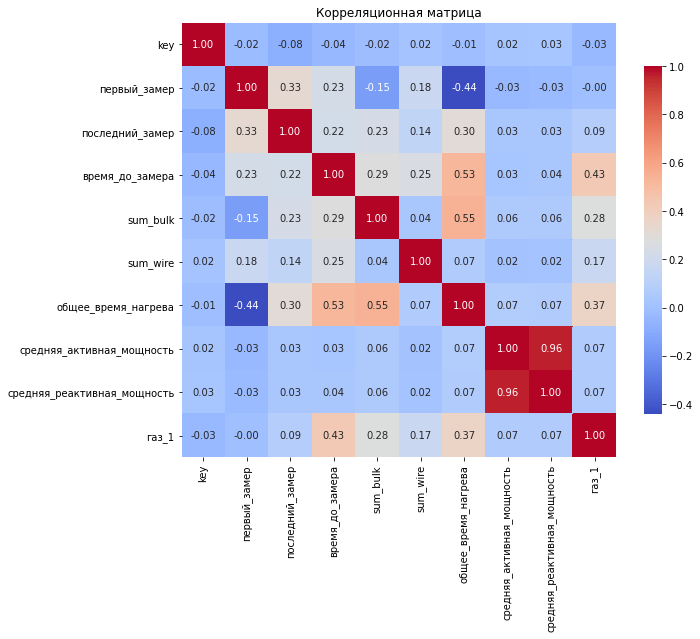

In [129]:
correlation_matrix = df_train.corr()

# Настройка размера фигуры
plt.figure(figsize=(10, 8))

# Создание тепловой карты
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})

# Заголовок графика
plt.title('Корреляционная матрица')

# Показать график
plt.show()


Мы можем увидеть очень сильную корреляцию в 0.96 между активной и реактивной мощностями, что вполне логично. Также есть корреляция между временем от первого замера температуры до последнего и общим временем нагрева, что также легко объясняется тем, что если мы очень долго нагревали партию, то соотественно и время между замерами увличивается. Также корреляция в -0.44 меджу общим временем нагрева и температурой на первом замере, что также объясняется сущностями этих признаков. Единственная корреляция, сущность возникновения которой мне не совсем ясная, эта корреляция в 0.55 между объемом сыпучих металлов и общим временем нагрева ( конечно есть предположение, что чем больше мы металла добавляем, тем долше его греть, но я не уерен что в данном случае это работает так). 

Далее я не собираюсь использовать линейные модели, так что и мультиколлинеарность для меня не проблема. В связи с этим обработку проводить не буду. 

## Модель.

### Создание модели.

In [130]:
X_train = df_train.drop(['последний_замер'], axis=1)
y_train = df_train['последний_замер']

X_test = df_test.drop(['последний_замер'], axis=1)
y_test = df_test['последний_замер']

num_columns = ['первый_замер','время_до_замера','sum_bulk','sum_wire','общее_время_нагрева',
               'средняя_активная_мощность'
               ,'средняя_реактивная_мощность','газ_1']

In [131]:
num_columns

['первый_замер',
 'время_до_замера',
 'sum_bulk',
 'sum_wire',
 'общее_время_нагрева',
 'средняя_активная_мощность',
 'средняя_реактивная_мощность',
 'газ_1']

In [132]:
data_preprocessor = ColumnTransformer(
    [('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)
pipe_final = Pipeline(
        [   ('preprocessor', data_preprocessor),
            ('models', DecisionTreeRegressor())
        ]
    )

In [133]:
def rands(param):
    rs_func = RandomizedSearchCV(
    pipe_final, 
    param_distributions=param, 
    scoring='neg_mean_absolute_error', 
    random_state=RANDOM_STATE,
    n_jobs=-1,
    n_iter=20,
    )
    return rs_func

def grids(param):
    gs_func = GridSearchCV(
    pipe_final, 
    param_grid=param, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1,
    )
    return gs_func

In [134]:
def results(model):
    model.fit(X_train, y_train)
    best_score = -model.best_score_
    fit_time = model.cv_results_['mean_fit_time'][model.best_index_]
    score_time = model.cv_results_['mean_score_time'][model.best_index_]
    print('Метрика MAE для лучшей модели:', best_score)
    print('Время обучения модели:', fit_time)
    print('Время предсказания модели:', score_time)

    
    return model, best_score, fit_time, score_time

In [135]:
param_distributions_rf = {'models': [RandomForestRegressor(random_state=RANDOM_STATE, n_jobs = -1)],
                          'models__max_depth': range(10, 12) ,'models__min_samples_leaf': range(10,12),
                          'models__max_features':(1,8)

     }    

In [136]:
param_distributions_cb = {
    'models': [CatBoostRegressor(random_state=RANDOM_STATE, verbose=0)],
    'models__depth': range(3, 6),
    'models__learning_rate': [0.01, 0.1, 0.2],
    'models__iterations': [100, 200],
    'models__loss_function' : ['MAE']
}

In [137]:
rf_model, rf_rmse, rf_fit_time,  rf_score_time=results(grids(param_distributions_rf))

Метрика MAE для лучшей модели: 6.5534477928111645
Время обучения модели: 0.44301958084106446
Время предсказания модели: 0.013465976715087891


In [138]:
cb_model, cb_rmse, cb_fit_time, cb_score_time = results(grids(param_distributions_cb))


Метрика MAE для лучшей модели: 6.324702807537379
Время обучения модели: 0.9318971633911133
Время предсказания модели: 0.0050353527069091795


При помощи пайплайна и перебора гиперпараметров было создано две модели: random forest и catoost, с метриками MAE на тренировочный выборке 6.5 и 6.3 соответсвенно. Так как метрика у catboost ниже, она выбирается, как лушчая модель и будет использоваться для пресдказания.

### Проверка модели на тестовой выборке.

In [139]:
model = cb_model.best_estimator_

In [140]:
pred = model.predict(X_test)

In [141]:
model.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(remainder='passthrough',
                     transformers=[('num', MinMaxScaler(),
                                    ['первый_замер', 'время_до_замера', 'sum_bulk',
                                     'sum_wire', 'общее_время_нагрева',
                                     'средняя_активная_мощность',
                                     'средняя_реактивная_мощность', 'газ_1'])])),
  ('models', <catboost.core.CatBoostRegressor at 0x7fdbf80caac0>)],
 'verbose': False,
 'preprocessor': ColumnTransformer(remainder='passthrough',
                   transformers=[('num', MinMaxScaler(),
                                  ['первый_замер', 'время_до_замера', 'sum_bulk',
                                   'sum_wire', 'общее_время_нагрева',
                                   'средняя_активная_мощность',
                                   'средняя_реактивная_мощность', 'газ_1'])]),
 'models': <catboost.core.CatBoostRegressor at 

In [142]:
mae_cat = mean_absolute_error(y_test, pred)
print(f"Mean absolute error (mae): {mae_cat}")

Mean absolute error (mae): 5.96533643515095


#### Проверка модели на устойчивость.

In [143]:
dummy_model = DummyRegressor(strategy='median')
dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
print(f'MAE DummyRegressor: {mae_dummy}')

if mae_dummy > mae_cat:
    print("CatBoost лучше базовой модели.")
else:
    print("Базовая модель лучше или на уровне CatBoost.")

MAE DummyRegressor: 7.583333333333333
CatBoost лучше базовой модели.


На тестовой выборке модель выдает метрику mae в 5.9, что нас удовлетворяет. Модель можно использовать.

Была проведена проверка на адектваность модели, путем ее сравениния с DummyRegressor, модель ее прошла 

Ее изменныне гиперпараметры:  'iterations': 200,  'learning_rate': 0.2,  'depth': 3,  'loss_function': 'Mae'.

### Важность признаков.

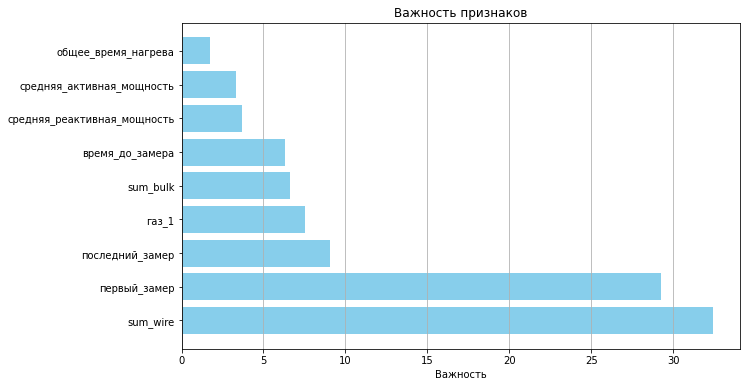

In [144]:
feature_importances = model.named_steps['models'].get_feature_importance()
feature_names = df_train.drop(['key'], axis=1).columns

# Создание DataFrame для визуализации
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Важность')
plt.title('Важность признаков')
plt.grid(axis='x')
plt.show()


На графике видно, что есть два признака, сильно лидириющие по важности: температура при первом замере и общий объем используемых проволочных материалов. Почему настолько важна первая температура интуитивно понятно, а вот важность проволочных материалов довольна интересна и возомжно требует дополнителього исследования.

## Вывод.

В ходе предобработки было выполнено:1)Изменение типа данных всех столбцов, содержащих в себе дату, на datetime64; 2) Обработка пропущенных занчений во всех датасетах или удаление строк с ними, если такой возможности не было.; 3) Было выяснено, что в данных нет дубликатов.
 
Далее, благодоря первичному исследоватлеьскому анализу данных, было выяснено:
    
Активаня мощность - пик на гистограмме у значения 0.5, а большинсвто значений находистя в диапозоне от 0.46 до 0.8.

Реактивная мощность - большинство занчений находится в пределах от 0.33 до 0.6.

Bulk 14 - основные 4 пика кол-ва добавок располагаются на значениях: 0,100,150,200.
    
Газ - Большинство значений расположено между 7 и 13.

Температура - Большинсвто значений расположено в диапозоне от 1580 до 1599

Wire 1 - виден пик на значении 100, большинство значений распологается в диапазоне от 70 до 125. 

После первичного анализа был создан итоговый датафрейм, который включает в себя и некоторые новосозданные признаки: Из датасета про электроды был создан новый, включающий в себя общее время нагрева дугой в секундах, среднюю активную и реактивную мощность на каждую партию;Из датафрейма об объеме сыпучих материалов был создан новый признак, включающий в себя сумму всех металлов;Был создан датафрейм включающий в себя температуру при первом и последнем замере, а также время в секундах между первым и последним замером; из датасета об объеме проволочных материалов был созданном новый признак, являющийся суммой всех материалов. Далее все эти признаки + объем использованного газа были объеденены в один датафрейм по номерам партий, которыйбыл разделен на тренировочную и тестовую выборку.

В итоге оказалось (Это было вполне ожидаемо), что распределение признаков в тестовой и тренировочной выборке одинаковое. Статистические выбросы удалялись только из тренировочной выборки. Вот, что было выяснено про каждый признак:

1) Температура на первом замере - Тренировочная выборка: пик значений на отметке в 1575. Большинство значений находися в диапазоне от 1571 до 1603; Тестовая выборка - Пик занчений на отметке в 1570. Большинство значений находится в диапазоне от 1569 до 1602.

2) Температура на последнем замере - Тренировочная выборка: Пик значений на отметке в 1588. Большинство значений находится в промежутке от 1588 до 1598.; Тестовая выборка - Большинство значений находится в диапозоне от 1587 до 1597.

3) Время между замерами температуры - Тренировочная выборка: Большинство значений находится в пределах от 1590 до 2758; Тестовая выборка - Большинство значений находится в диапозоне от 1538 до 2750.

4) Объем сыпучих материаллов - Тренировочная выборка: Большинство значений расположено в диапазоне от 434 до 789.; Тестовая выборка - Большинство значений расположено в диапозоне от 450 до 796.

5) Объем проволочных материаллов - Тренировочная выборка: Четко виден пик на значении в 100. Большинство значений распределены в промежутке от 88 до 151; Тестовая выборка - Также виден пик на значении в 100. Большинство значений расположено в промежутке от 7 до 147.

6) Активная мощность - Тренировочная выборка: Большинство значений расположено в промежутке от 0.57 до 0.73; Тестовая выборка - Большинство значений расположено в промежутке от 0.58 до 0.75.

7) Реактивная мощность - Тренировочная выборка: Большинство значений расположен в промежутке от 0.41 до 0.54.; Тестовая выборка - Большинсвто значений расположено в промежутке от 0.41 до 0.55.

8) Время нагрева - Тренировочная выборка: Большинство значений находится в диапозоне от 586 до 996.; Тестовая выборка - Большинство значений находится в диапозоне от 564 до 952.

9) Газ - Тренировочная выборка: Четко виден пик на значении в 10.Большинсвто занчений расположено в диапозоне от 7 до 14; Тестовая выборка -Большинство занчений лежит в пределах от 7 до 13.

Далее, при помощи пайплайна и перебора гиперпараметров было создано две модели для предсказания температуры на последнем замере: random forest и catboost. CatBoost  показал более хорошую метрику при обучении, так что эта модель была выбрана для дальнейшей работы. На тестовой выборке она выдала метрику MAE в 5.9, это говорит о том, что модель можно использовать (пороговое значение в 6.8 было преодалено).Была проведена проверка на адектваность модели, путем ее сравениния с DummyRegressor, модель ее прошла. Был также проведен анализ важности признаков созданной модели, в ходе которого было выяснено, что есть два признака, сильно лидириющие по важности: температура при первом замере и общий объем используемых проволочных материалов. Почему настолько важна первая температура интуитивно понятно, а вот важность проволочных материалов довольна интеесна и возомжно требует дополнителього исследовани.

Для улучшения результатов данного исследования может пригодится более широкий по объему датасет и некоторые дополниетльные уточнения по поводу технического процесса.